# Notebook 03 — Temporal Analysis: Summary of Findings

## Overview
This notebook investigates the transaction network as it evolves over time, 
moving beyond the static graph built in notebook 02. Two major discoveries 
emerged: a natural activity cycle length of ~24 steps (not calendar days), 
and a structural regime change partway through the simulation with 
significant implications for fraud detection strategy.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pickle 
import os

# load filtered transactions
df = pd.read_csv('../data/processed/filtered_transactions.csv')
print(f"Transactions loaded: {df.shape}")
print(f"Time steps available: {df['step'].min()} to {df['step'].max()}")
print(f"Total steps: {df['step'].nunique()}")



Transactions loaded: (2770393, 11)
Time steps available: 1 to 743
Total steps: 743


In [3]:
# How many transactions are there per time step?
transactions_per_step = df.groupby('step').size()
fraud_per_step = df[df['isFraud']==1].groupby('step').size()

print(f"Avg transactions per step: {transactions_per_step.mean():.2f}")
print(f"Max transactions in one step: {transactions_per_step.max()}")
print(f"Min transactions in one step: {transactions_per_step.min()}")
print(f"\nSteps containing fraud: {len(fraud_per_step)}")
print(f"Avg fraud transactions per step: {fraud_per_step.mean():.2f}")
print(f"Max fraud transactions in one step: {fraud_per_step.max()}")


Avg transactions per step: 3728.66
Max transactions in one step: 23768
Min transactions in one step: 2

Steps containing fraud: 741
Avg fraud transactions per step: 11.06
Max fraud transactions in one step: 39


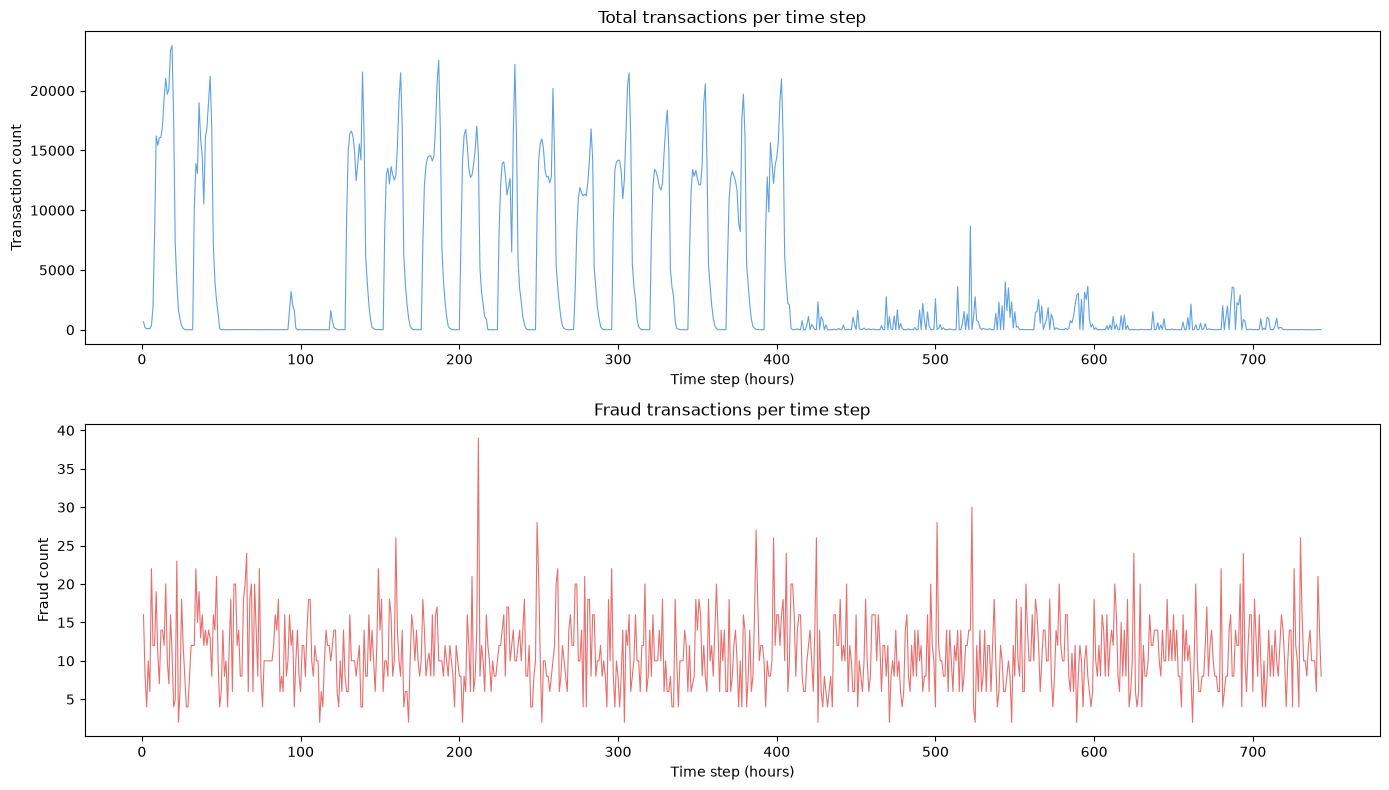

Figure saved.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot total transactions per step
axes[0].plot(transactions_per_step.index, 
             transactions_per_step.values, 
             color='#378ADD', linewidth=0.8, alpha=0.8)
axes[0].set_title('Total transactions per time step')
axes[0].set_xlabel('Time step (hours)')
axes[0].set_ylabel('Transaction count')

# Plot fraud transactions per step
axes[1].plot(fraud_per_step.index,
             fraud_per_step.values,
             color='#E24B4A', linewidth=0.8, alpha=0.8)
axes[1].set_title('Fraud transactions per time step')
axes[1].set_xlabel('Time step (hours)')
axes[1].set_ylabel('Fraud count')

plt.tight_layout()
plt.savefig('../results/figures/transactions_over_time.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [5]:
# create directory for dialy snapshots
os.makedirs('../data/processed/daily_snapshots', exist_ok=True)

#Define daily windows (24 steps per day)

steps_per_day = 24
max_step = df['step'].max()
num_days = int(np.ceil((max_step) / steps_per_day))

print(f'Steps per day: {steps_per_day}')
print(f"Max step: {max_step}")
print(f"Number of daily snapshots: {num_days}")


Steps per day: 24
Max step: 743
Number of daily snapshots: 31


In [6]:
# Convert steps to days (each day = 24)
df['day'] = ((df['step'] - 1) // 24) + 1

print(f"Days in dataset: {df['day'].min()} to {df['day'].max()}")
print(f"Transactions per day (sample):")
print(df.groupby('day').size().head(10))

Days in dataset: 1 to 31
Transactions per day (sample):
day
1     251083
2     202874
3        429
4       8766
5       2675
6     195910
7     186059
8     197042
9     181648
10    171830
dtype: int64


Steps with fewer than 100 transactions: 367

 First 20 low activity steps:
step
3     87
5     91
27    23
28     4
29     4
30     8
31    12
32    12
50     6
51    14
52     8
53    10
54     4
55    12
56    18
57     6
58    20
59    20
60    12
61    14
dtype: int64


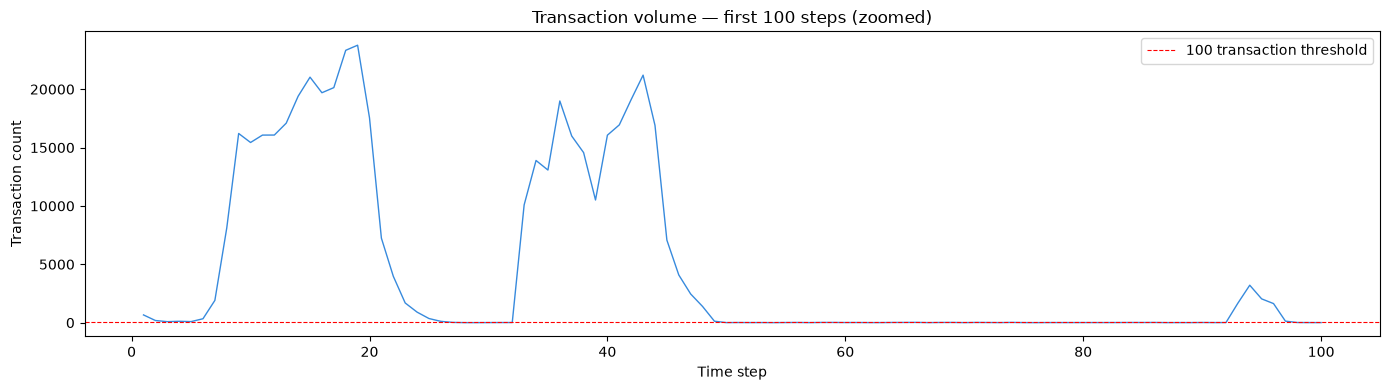

In [7]:
# Look at the transaction volume per step to find natural day boundaries
transactions_per_step = df.groupby('step').size()

# find steps with very lown activity(likely overnight/day boundaries)

low_activity_steps = transactions_per_step[transactions_per_step < 100]
print(f"Steps with fewer than 100 transactions: {len(low_activity_steps)}")
print(f"\n First 20 low activity steps:")
print(low_activity_steps.head(20))

# Plot first 100 steps steps closely to see cycle clearly
plt.figure(figsize=(14, 4))
plt.plot(transactions_per_step.index[:100], 
         transactions_per_step.values[:100],
         color='#378ADD', linewidth=1)
plt.axhline(y=100, color='red', linestyle='--', linewidth=0.8, label='100 transaction threshold')
plt.title('Transaction volume — first 100 steps (zoomed)')
plt.xlabel('Time step')
plt.ylabel('Transaction count')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/step_cycle_zoom.png', dpi=150, bbox_inches='tight')
plt.show()



In [8]:
# Find where low activity starts and ends
low_activity = transactions_per_step < 100

trough_starts = []
in_trough = False

for step in transactions_per_step.index:
    if low_activity[step] and not in_trough:
        trough_starts.append(step)
        in_trough = True
    elif not low_activity[step]:
        in_trough = False

print(f"Trough start steps (first 15): {trough_starts[:15]}")

gaps = [trough_starts[i+1] - trough_starts[i] for i in range(len(trough_starts)-1)]
print(f"\nGaps between troughs (first 15): {gaps[:15]}")
print(f"Most common gap: {max(set(gaps), key=gaps.count)}")
print(f"Average gap: {np.mean(gaps):.2f}")
print(f"Median gap: {np.median(gaps):.2f}")

Trough start steps (first 15): [3, 5, 27, 50, 98, 122, 147, 170, 195, 218, 243, 267, 290, 314, 337]

Gaps between troughs (first 15): [2, 22, 23, 48, 24, 25, 23, 25, 23, 25, 24, 23, 24, 23, 26]
Most common gap: 2
Average gap: 8.23
Median gap: 3.00


## Finding 1: Natural activity cycles, not calendar days

Transaction volume follows a clear cyclical pattern — bursts of activity 
followed by near-total quiet periods, repeating roughly every 24 steps. 
Naive bucketing from step 1 misaligned with these natural cycles, producing 
artificially uneven "days." Detecting trough boundaries directly from the 
data (steps where activity drops below 100 transactions) revealed the true 
cycle structure: warmup from steps 1-6, then consistent ~24-step cycles 
starting at step 7.

This matters methodologically: any time-based feature built on misaligned 
windows would be measuring an artefact of the bucketing choice, not real 
network behaviour.

In [9]:
# The first real cycle boundary starts at step 27
# Cycles are approximately 24 steps long.
# So we bucket based on distance from step 27

CYCLE_START = 7
CYCLE_LENGTH = 28

def assign_cycle(step):
    if step < CYCLE_START:
        return 0
    else:
        return ((step - CYCLE_START) // CYCLE_LENGTH) + 1
    
df['cycle'] = df['step'].apply(assign_cycle)
cycle_counts = df.groupby('cycle').size()
print(f"Cycle identified: {df['cycle'].nunique()}")
print(f"transactions per cycle (first 10):")
print(cycle_counts.head(10))
print(f"\n Cycle 0 (warmup) : {cycle_counts.get(0,0)} transactions")
print(f"Average transactions per real cycle: {cycle_counts[cycle_counts.index > 0].mean():.0f}")
print(f"Std deviation across cycles: {cycle_counts[cycle_counts.index > 0].std():.0f}")

Cycle identified: 28
transactions per cycle (first 10):
cycle
0      1482
1    274112
2    178638
3       352
4      8918
5    198541
6    186214
7    218421
8    232976
9    233852
dtype: int64

 Cycle 0 (warmup) : 1482 transactions
Average transactions per real cycle: 102552
Std deviation across cycles: 99929


In [10]:
# Print step-by-step transaction counts around the first trough
print("Step-by-step counts around first trough:")
for step in range(1, 60):
    count = transactions_per_step.get(step, 0)
    bar = '█' * (count // 500)
    print(f"Step {step:3d}: {count:6d} {bar}")

Step-by-step counts around first trough:
Step   1:    664 █
Step   2:    185 
Step   3:     87 
Step   4:    119 
Step   5:     91 
Step   6:    336 
Step   7:   1907 ███
Step   8:   8114 ████████████████
Step   9:  16207 ████████████████████████████████
Step  10:  15434 ██████████████████████████████
Step  11:  16068 ████████████████████████████████
Step  12:  16072 ████████████████████████████████
Step  13:  17092 ██████████████████████████████████
Step  14:  19397 ██████████████████████████████████████
Step  15:  21031 ██████████████████████████████████████████
Step  16:  19697 ███████████████████████████████████████
Step  17:  20135 ████████████████████████████████████████
Step  18:  23330 ██████████████████████████████████████████████
Step  19:  23768 ███████████████████████████████████████████████
Step  20:  17543 ███████████████████████████████████
Step  21:   7238 ██████████████
Step  22:   3977 ███████
Step  23:   1688 ███
Step  24:    903 █
Step  25:    355 
Step  26:    112 

In [11]:
# Use troughs as natural cycle boundaries
# A trough is any step with fewer than 100 transactions
low_activity = transactions_per_step < 100

# Find trough end points (where activity resumes after a quiet period)
cycle_boundaries = [1]  # always start from step 1
in_trough = False

for step in transactions_per_step.index:
    if low_activity[step] and not in_trough:
        in_trough = True
    elif not low_activity[step] and in_trough:
        # Activity just resumed — this is a new cycle start
        cycle_boundaries.append(step)
        in_trough = False

print(f"Cycle boundaries found: {len(cycle_boundaries)}")
print(f"First 15 boundaries: {cycle_boundaries[:15]}")
print(f"\nCycle lengths:")
lengths = [cycle_boundaries[i+1] - cycle_boundaries[i] 
           for i in range(min(14, len(cycle_boundaries)-1))]
print(lengths)

Cycle boundaries found: 88
First 15 boundaries: [1, 4, 6, 33, 93, 119, 129, 153, 177, 201, 225, 249, 273, 297, 321]

Cycle lengths:
[3, 2, 27, 60, 26, 10, 24, 24, 24, 24, 24, 24, 24, 24]


In [12]:
# Real cycles start from step 129 with consistent 24 step length
# Everything before is warmup

REAL_CYCLE_START = cycle_boundaries[6]  # step 129
CYCLE_LENGTH = 24

print(f"Real cycles start at step: {REAL_CYCLE_START}")

def assign_cycle(step):
    if step < REAL_CYCLE_START:
        return 0  # warmup
    else:
        return ((step - REAL_CYCLE_START) // CYCLE_LENGTH) + 1

df['cycle'] = df['step'].apply(assign_cycle)

cycle_counts = df.groupby('cycle').size()
real_cycles = cycle_counts[cycle_counts.index > 0]

print(f"\nTotal cycles: {len(real_cycles)}")
print(f"\nTransactions per cycle (first 10):")
print(real_cycles.head(10))
print(f"\nWarmup transactions: {cycle_counts.get(0, 0):,}")
print(f"Average per real cycle: {real_cycles.mean():.0f}")
print(f"Std deviation: {real_cycles.std():.0f}")
print(f"Min cycle: {real_cycles.min():,}")
print(f"Max cycle: {real_cycles.max():,}")

Real cycles start at step: 129

Total cycles: 26

Transactions per cycle (first 10):
cycle
1     195946
2     186120
3     197053
4     182133
5     171470
6     182025
7     149239
8     188645
9     172337
10    174222
dtype: int64

Warmup transactions: 466,209
Average per real cycle: 88622
Std deviation: 86239
Min cycle: 179
Max cycle: 197,053


In [13]:
print("All cycle counts:")
print(cycle_counts)

All cycle counts:
cycle
0     466209
1     195946
2     186120
3     197053
4     182133
5     171470
6     182025
7     149239
8     188645
9     172337
10    174222
11    163131
12    188325
13      7269
14      4240
15      8231
16     10088
17     21596
18     20513
19     14104
20     24548
21      4985
22      4387
23      5121
24     23298
25      4979
26       179
dtype: int64


In [14]:
regime1 = df[df['cycle'].between(1,12)]
regime2 = df[df['cycle'].between(13,26)]

print("===Regime 1(cycles1-12)===")

print(f"Transactions: {len(regime1)}:,")
print(f"Fraud transactions: {regime1['isFraud'].sum():,}")
print(f"Fraud rate: {regime1['isFraud'].mean() * 100:.4f}%")
print(f"Avg transaction amount: ${regime1['amount'].mean():,.2f}")

print("\n=== Regime 2 (cycles 13-26) ===")
print(f"Transactions: {len(regime2):,}")
print(f"Fraud transactions: {regime2['isFraud'].sum():,}")
print(f"Fraud rate: {regime2['isFraud'].mean() * 100:.4f}%")
print(f"Avg transaction amount: ${regime2['amount'].mean():,.2f}")

print("\n=== Warmup (cycle 0) ===")
warmup = df[df['cycle'] == 0]
print(f"Transactions: {len(warmup):,}")
print(f"Fraud transactions: {warmup['isFraud'].sum():,}")
print(f"Fraud rate: {warmup['isFraud'].mean() * 100:.4f}%")

===Regime 1(cycles1-12)===
Transactions: 2150646:,
Fraud transactions: 3,223
Fraud rate: 0.1499%
Avg transaction amount: $327,935.03

=== Regime 2 (cycles 13-26) ===
Transactions: 153,538
Fraud transactions: 3,494
Fraud rate: 2.2757%
Avg transaction amount: $315,315.21

=== Warmup (cycle 0) ===
Transactions: 466,209
Fraud transactions: 1,480
Fraud rate: 0.3175%


## Finding 2: A structural regime change at cycle 13

Transaction volume collapses dramatically after cycle 12 — from ~175,000 
transactions/cycle down to under 10,000. Rather than treating this as noise, 
we tested whether fraud behaviour actually differs across the boundary 
before deciding how to handle it.

| | Regime 1 (cycles 1-12) | Regime 2 (cycles 13-26) |
|---|---|---|
| Transactions | 2,150,646 | 153,538 |
| Fraud rate | 0.15% | 2.28% |
| Avg transaction amount | $327,935 | $315,315 |

Fraud rate is **15x higher** in regime 2 despite the amount distribution 
staying similar. This confirms the regime change is a real structural shift 
in network dynamics, not a data artefact — and it directly shaped how the 
rest of this notebook (and later modelling) treats the two periods.

In [15]:
regime1_fraud_orig = set(regime1[regime1['isFraud']==1]['nameOrig'])
regime1_fraud_dest = set(regime1[regime1['isFraud']==1]['nameDest'])

regime2_fraud_orig = set(regime2[regime2['isFraud']==1]['nameOrig'])
regime2_fraud_dest = set(regime2[regime2['isFraud']==1]['nameDest'])

# How many fraud accounts are shared between regimes

shared_orig = regime1_fraud_orig & regime2_fraud_orig
shared_dest = regime1_fraud_dest & regime2_fraud_dest

print("=== Fraud account overlap between regimes ===")
print(f"Regime 1 fraud originators: {len(regime1_fraud_orig):,}")
print(f"Regime 2 fraud originators: {len(regime2_fraud_orig):,}")
print(f"Shared fraud originators: {len(shared_orig):,}")

print(f"\nRegime 1 fraud receivers: {len(regime1_fraud_dest):,}")
print(f"Regime 2 fraud receivers: {len(regime2_fraud_dest):,}")
print(f"Shared fraud receivers: {len(shared_dest):,}")

print("\n=== Transaction types per regime ===")
print("Regime 1:")
print(regime1['type'].value_counts())
print("\nRegime 2:")
print(regime2['type'].value_counts())

=== Fraud account overlap between regimes ===
Regime 1 fraud originators: 3,223
Regime 2 fraud originators: 3,494
Shared fraud originators: 0

Regime 1 fraud receivers: 3,213
Regime 2 fraud receivers: 3,490
Shared fraud receivers: 13

=== Transaction types per regime ===
Regime 1:
type
CASH_OUT    1741530
TRANSFER     409116
Name: count, dtype: int64

Regime 2:
type
CASH_OUT    118460
TRANSFER     35078
Name: count, dtype: int64


## Finding 3: Regime 1 and Regime 2 involve entirely different fraud actors

- Zero shared fraud originators between regimes (0 out of 3,223 / 3,494)
- Only 13 shared fraud receivers out of ~6,700 total across both regimes
- Transaction type ratios (CASH_OUT:TRANSFER) are consistent across regimes

This is not the same fraud campaign continuing — it's a complete turnover 
of fraudulent actors, using the same methods, in a structurally different 
network environment. This resembles real-world fraud ring dynamics: rings 
operate, get partially disrupted, and new rings emerge using similar tactics.

**Decision:** build snapshot graphs for both regimes to characterise them, 
but use only regime 1 for the main feature engineering and modelling 
pipeline, since regime 2 cycles are too sparse (some under 200 transactions) 
for reliable graph statistics. Regime 2 is documented as a high-fraud-density 
environment and proposed as a candidate for regime-aware modelling 
(Markov-switching models) in future work, once covered formally in the 
stochastic processes coursework this project runs alongside.

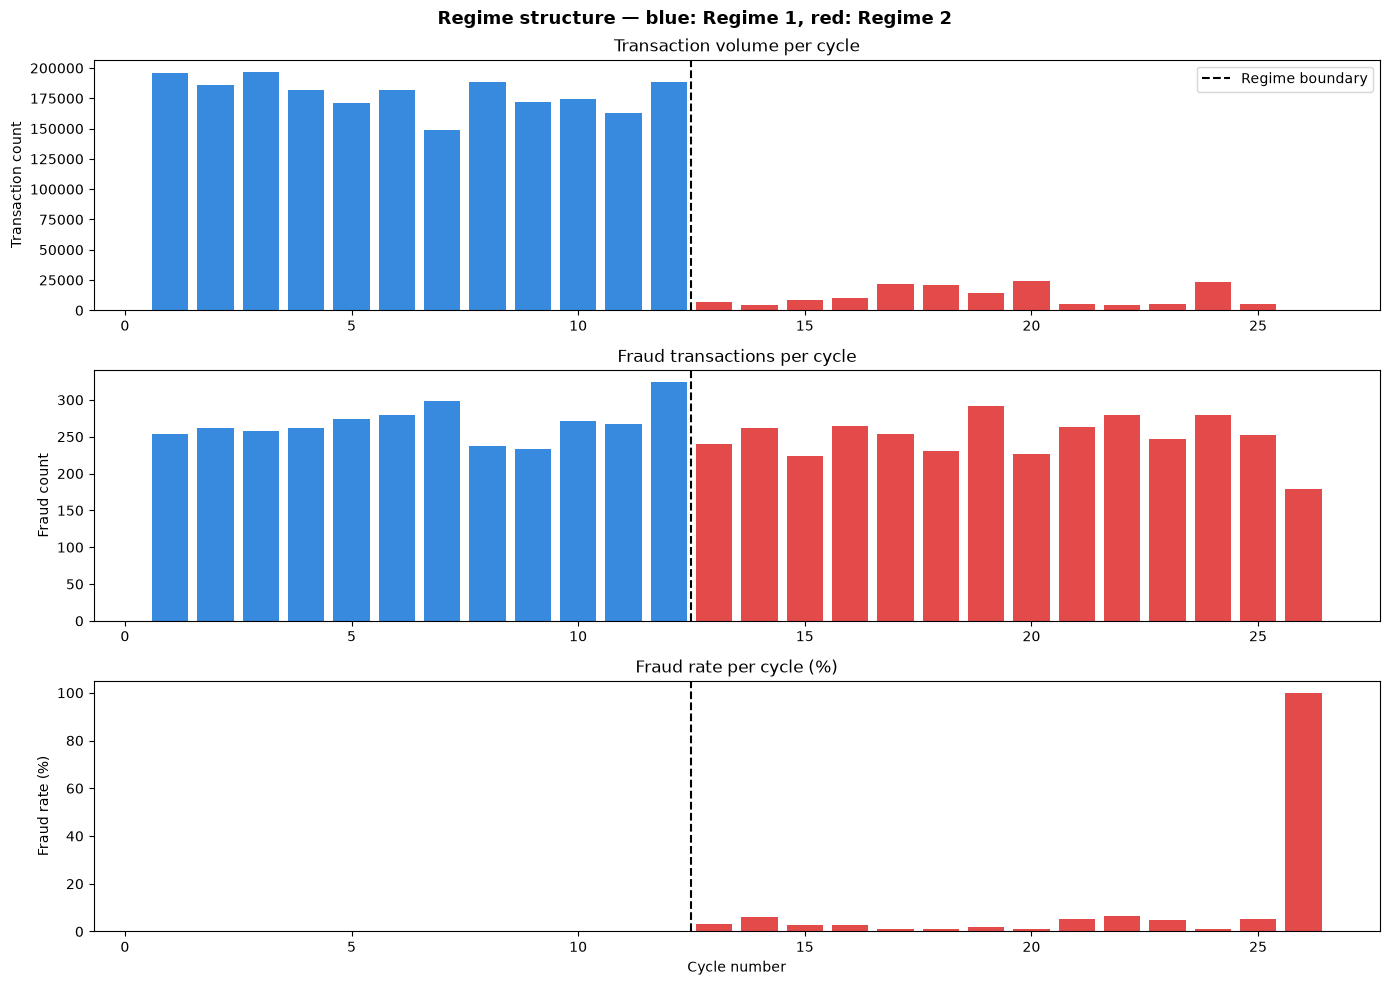

Figure saved.


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Transaction volume per cycle
cycle_counts_real = df[df['cycle'] > 0].groupby('cycle').size()
colors_vol = ['#378ADD' if c <= 12 else '#E24B4A' 
              for c in cycle_counts_real.index]

axes[0].bar(cycle_counts_real.index, cycle_counts_real.values, 
            color=colors_vol, width=0.8)
axes[0].set_title('Transaction volume per cycle')
axes[0].set_ylabel('Transaction count')
axes[0].axvline(x=12.5, color='black', linestyle='--', 
                linewidth=1.5, label='Regime boundary')
axes[0].legend()

# Plot 2: Fraud count per cycle
fraud_per_cycle = df[df['cycle'] > 0].groupby('cycle')['isFraud'].sum()
colors_fraud = ['#378ADD' if c <= 12 else '#E24B4A' 
                for c in fraud_per_cycle.index]

axes[1].bar(fraud_per_cycle.index, fraud_per_cycle.values,
            color=colors_fraud, width=0.8)
axes[1].set_title('Fraud transactions per cycle')
axes[1].set_ylabel('Fraud count')
axes[1].axvline(x=12.5, color='black', linestyle='--', linewidth=1.5)

# Plot 3: Fraud rate per cycle
fraud_rate_per_cycle = df[df['cycle'] > 0].groupby('cycle')['isFraud'].mean() * 100
colors_rate = ['#378ADD' if c <= 12 else '#E24B4A' 
               for c in fraud_rate_per_cycle.index]

axes[2].bar(fraud_rate_per_cycle.index, fraud_rate_per_cycle.values,
            color=colors_rate, width=0.8)
axes[2].set_title('Fraud rate per cycle (%)')
axes[2].set_ylabel('Fraud rate (%)')
axes[2].set_xlabel('Cycle number')
axes[2].axvline(x=12.5, color='black', linestyle='--', linewidth=1.5)

plt.suptitle('Regime structure — blue: Regime 1, red: Regime 2', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/regime_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [24]:
os.makedirs('../data/processed/cycle_snapshots',exist_ok = True)

regime1_df = df[df['cycle'].between(1,12)]
cycle_stats = []

for cycle in range(1,13):
    cycle_df = regime1_df[regime1_df['cycle'] == cycle]
    
    G_cycle = nx.DiGraph()
    
    for _, row in cycle_df.iterrows():
        G_cycle.add_edge(
            row['nameOrig'],
            row['nameDest'],
            weight=row['amount'],
            isFraud=row['isFraud'],
            step=row['step']
        )
    fraud_edges = sum(1 for u,v,d in G_cycle.edges(data=True) if d['isFraud'] == 1)
    in_degrees = dict(G_cycle.in_degree())
    
    cycle_stats.append({
        'cycle': cycle,
        'nodes': G_cycle.number_of_nodes(),
        'edges': G_cycle.number_of_edges(),
        'fraud_edges': fraud_edges,
        'fraud_rate': fraud_edges / G_cycle.number_of_edges() * 100,
        'avg_in_degree': np.mean(list(in_degrees.values())),
        'max_in_degree': max(in_degrees.values())
        
    })
    with open(f'../data/processed/cycle_snapshots/cycle_{cycle:02d}.pkl', 'wb') as f:
        pickle.dump(G_cycle, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f"Cycle {cycle:02d}: {G_cycle.number_of_nodes():,} nodes, "
          f"{G_cycle.number_of_edges():,} edges, "
          f"{fraud_edges} fraud ({fraud_edges/G_cycle.number_of_edges()*100:.2f}%)")

cycle_stats_df = pd.DataFrame(cycle_stats)
print(f"\nAll regime 1 snapshots built and saved.")

Cycle 01: 294,805 nodes, 195,946 edges, 254 fraud (0.13%)
Cycle 02: 296,185 nodes, 186,120 edges, 262 fraud (0.14%)
Cycle 03: 321,703 nodes, 197,053 edges, 258 fraud (0.13%)
Cycle 04: 309,002 nodes, 182,133 edges, 262 fraud (0.14%)
Cycle 05: 297,481 nodes, 171,470 edges, 274 fraud (0.16%)
Cycle 06: 319,046 nodes, 182,025 edges, 279 fraud (0.15%)
Cycle 07: 269,641 nodes, 149,239 edges, 299 fraud (0.20%)
Cycle 08: 333,932 nodes, 188,645 edges, 238 fraud (0.13%)
Cycle 09: 310,956 nodes, 172,337 edges, 234 fraud (0.14%)
Cycle 10: 317,018 nodes, 174,222 edges, 272 fraud (0.16%)
Cycle 11: 300,400 nodes, 163,131 edges, 267 fraud (0.16%)
Cycle 12: 345,123 nodes, 188,325 edges, 324 fraud (0.17%)

All regime 1 snapshots built and saved.


## Finding 4: Fraud is stable within Regime 1, but its structural concentration varies

Across the 12 regime 1 cycles, fraud transaction count stays remarkably 
consistent (234-324 per cycle) and fraud rate stays tight (0.13%-0.20%). 
However max in-degree per cycle fluctuates independently of fraud count — 
cycle 12 has the highest fraud count (324) but a relatively low max 
in-degree (6), showing that fraud is not always concentrated at a single 
hub account. Sometimes it is distributed across many moderately-connected 
accounts instead.

This is an important modelling implication: in-degree alone will not 
reliably catch every fraud pattern. Multiple structural features, not one, 
are needed for robust detection.

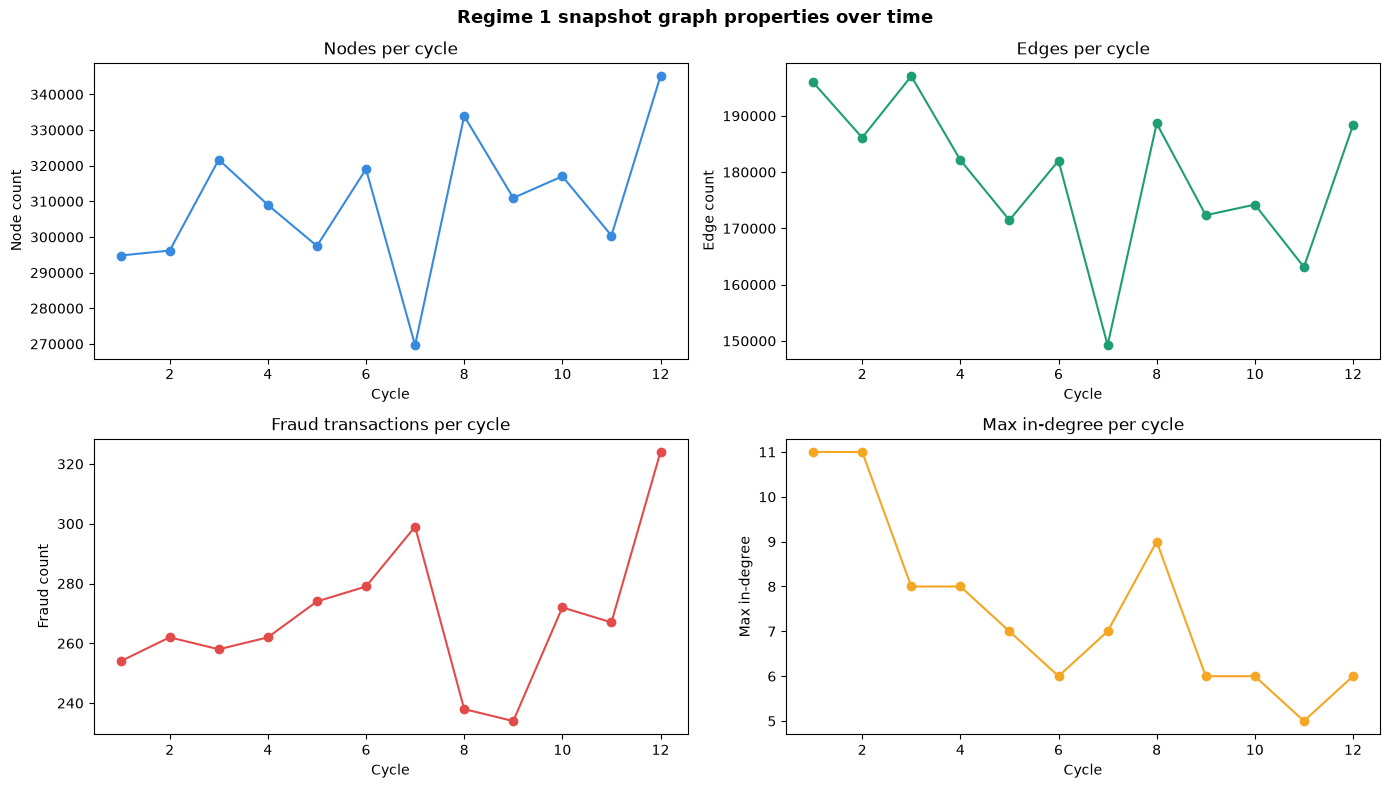

Figure saved.


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

cycles = cycle_stats_df['cycle']

# Plot 1: Nodes per cycle
axes[0,0].plot(cycles, cycle_stats_df['nodes'], 
               color='#378ADD', marker='o', linewidth=1.5)
axes[0,0].set_title('Nodes per cycle')
axes[0,0].set_ylabel('Node count')
axes[0,0].set_xlabel('Cycle')

# Plot 2: Edges per cycle
axes[0,1].plot(cycles, cycle_stats_df['edges'],
               color='#1D9E75', marker='o', linewidth=1.5)
axes[0,1].set_title('Edges per cycle')
axes[0,1].set_ylabel('Edge count')
axes[0,1].set_xlabel('Cycle')

# Plot 3: Fraud count per cycle
axes[1,0].plot(cycles, cycle_stats_df['fraud_edges'],
               color='#E24B4A', marker='o', linewidth=1.5)
axes[1,0].set_title('Fraud transactions per cycle')
axes[1,0].set_ylabel('Fraud count')
axes[1,0].set_xlabel('Cycle')

# Plot 4: Max in-degree per cycle
axes[1,1].plot(cycles, cycle_stats_df['max_in_degree'],
               color='#F5A623', marker='o', linewidth=1.5)
axes[1,1].set_title('Max in-degree per cycle')
axes[1,1].set_ylabel('Max in-degree')
axes[1,1].set_xlabel('Cycle')

plt.suptitle('Regime 1 snapshot graph properties over time',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/snapshot_properties.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [26]:
cycle_fraud_receivers = {}

for cycle in range(1,13):
    cycle_df = regime1_df[regime1_df['cycle'] == cycle]
    receivers = set(cycle_df[cycle_df['isFraud']==1]['nameDest'])
    cycle_fraud_receivers[cycle] = receivers
    
# Check overlap between consecutive cycles

print("Fraud reciever overlap between consecutive cycles:")
for cycle in range(1,12):
    overlap = cycle_fraud_receivers[cycle] & cycle_fraud_receivers[cycle+1]
    print(f"Cycle {cycle:02d} -> {cycle+1:02d}"
        f"{len(cycle_fraud_receivers[cycle])} receivers, "
        f"{len(cycle_fraud_receivers[cycle+1])} receivers, "
        f"{len(overlap)} shared")  
          
# Check if any receiver appears in all 12 cycles
all_cycles_receivers = cycle_fraud_receivers[1]
for cycle in range(2, 13):
    all_cycles_receivers = all_cycles_receivers & cycle_fraud_receivers[cycle]
print(f"\nReceivers appearing in all 12 cycles: {len(all_cycles_receivers)}")

# Check receivers appearing in 6+ cycles
from collections import Counter
receiver_cycle_counts = Counter()
for cycle, receivers in cycle_fraud_receivers.items():
    for r in receivers:
        receiver_cycle_counts[r] += 1

persistent = {r: c for r, c in receiver_cycle_counts.items() if c >= 6}
print(f"Receivers appearing in 6+ cycles: {len(persistent)}")
if persistent:
    print("Most persistent receivers:")
    for r, c in sorted(persistent.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {r}: {c} cycles")        

Fraud reciever overlap between consecutive cycles:
Cycle 01 -> 02254 receivers, 262 receivers, 0 shared
Cycle 02 -> 03262 receivers, 258 receivers, 0 shared
Cycle 03 -> 04258 receivers, 262 receivers, 0 shared
Cycle 04 -> 05262 receivers, 274 receivers, 0 shared
Cycle 05 -> 06274 receivers, 279 receivers, 1 shared
Cycle 06 -> 07279 receivers, 298 receivers, 1 shared
Cycle 07 -> 08298 receivers, 238 receivers, 0 shared
Cycle 08 -> 09238 receivers, 234 receivers, 0 shared
Cycle 09 -> 10234 receivers, 272 receivers, 0 shared
Cycle 10 -> 11272 receivers, 267 receivers, 0 shared
Cycle 11 -> 12267 receivers, 324 receivers, 0 shared

Receivers appearing in all 12 cycles: 0
Receivers appearing in 6+ cycles: 0


In [27]:
# Build snapshot graphs for regime 2 cycles
os.makedirs('../data/processed/cycle_snapshots/regime2', exist_ok=True)

regime2_df = df[df['cycle'].between(13, 26)]
cycle_stats_r2 = []

for cycle in range(13, 27):
    cycle_df = regime2_df[regime2_df['cycle'] == cycle]
    
    if len(cycle_df) == 0:
        print(f"Cycle {cycle:02d}: empty — skipping")
        continue
    
    G_cycle = nx.DiGraph()
    
    for _, row in cycle_df.iterrows():
        G_cycle.add_edge(
            row['nameOrig'],
            row['nameDest'],
            weight=row['amount'],
            isFraud=row['isFraud'],
            step=row['step']
        )
    
    fraud_edges = sum(1 for u, v, d in G_cycle.edges(data=True) 
                      if d['isFraud'] == 1)
    
    in_degrees = dict(G_cycle.in_degree())
    
    cycle_stats_r2.append({
        'cycle': cycle,
        'nodes': G_cycle.number_of_nodes(),
        'edges': G_cycle.number_of_edges(),
        'fraud_edges': fraud_edges,
        'fraud_rate': fraud_edges / G_cycle.number_of_edges() * 100,
        'avg_in_degree': np.mean(list(in_degrees.values())),
        'max_in_degree': max(in_degrees.values())
    })
    
    with open(f'../data/processed/cycle_snapshots/regime2/cycle_{cycle:02d}.pkl', 'wb') as f:
        pickle.dump(G_cycle, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f"Cycle {cycle:02d}: {G_cycle.number_of_nodes():,} nodes, "
          f"{G_cycle.number_of_edges():,} edges, "
          f"{fraud_edges} fraud ({fraud_edges/G_cycle.number_of_edges()*100:.2f}%)")

cycle_stats_r2_df = pd.DataFrame(cycle_stats_r2)
print(f"\nAll regime 2 snapshots built and saved.")


Cycle 13: 14,488 nodes, 7,269 edges, 240 fraud (3.30%)
Cycle 14: 8,462 nodes, 4,240 edges, 262 fraud (6.18%)
Cycle 15: 16,405 nodes, 8,231 edges, 224 fraud (2.72%)
Cycle 16: 20,090 nodes, 10,088 edges, 264 fraud (2.62%)
Cycle 17: 42,746 nodes, 21,596 edges, 254 fraud (1.18%)
Cycle 18: 40,652 nodes, 20,513 edges, 231 fraud (1.13%)
Cycle 19: 28,031 nodes, 14,104 edges, 292 fraud (2.07%)
Cycle 20: 48,545 nodes, 24,548 edges, 227 fraud (0.92%)
Cycle 21: 9,950 nodes, 4,985 edges, 263 fraud (5.28%)
Cycle 22: 8,757 nodes, 4,387 edges, 280 fraud (6.38%)
Cycle 23: 10,220 nodes, 5,121 edges, 247 fraud (4.82%)
Cycle 24: 46,074 nodes, 23,298 edges, 279 fraud (1.20%)
Cycle 25: 9,945 nodes, 4,979 edges, 252 fraud (5.06%)
Cycle 26: 358 nodes, 179 edges, 179 fraud (100.00%)

All regime 2 snapshots built and saved.


In [28]:
# Track fraud receiver persistence across regime 2 cycles
cycle_fraud_receivers_r2 = {}

for cycle in range(13, 27):
    cycle_df = regime2_df[regime2_df['cycle'] == cycle]
    receivers = set(cycle_df[cycle_df['isFraud']==1]['nameDest'])
    cycle_fraud_receivers_r2[cycle] = receivers

# Check overlap between consecutive cycles
print("Fraud receiver overlap between consecutive cycles — Regime 2:")
for cycle in range(13, 26):
    overlap = cycle_fraud_receivers_r2[cycle] & cycle_fraud_receivers_r2[cycle+1]
    print(f"  Cycle {cycle:02d} → {cycle+1:02d}: "
          f"{len(cycle_fraud_receivers_r2[cycle])} receivers, "
          f"{len(cycle_fraud_receivers_r2[cycle+1])} receivers, "
          f"{len(overlap)} shared")

# Check receivers appearing in all regime 2 cycles
all_r2_receivers = cycle_fraud_receivers_r2[13]
for cycle in range(14, 27):
    all_r2_receivers = all_r2_receivers & cycle_fraud_receivers_r2[cycle]
print(f"\nReceivers appearing in all 14 regime 2 cycles: {len(all_r2_receivers)}")

# Check receivers appearing in 6+ cycles
receiver_cycle_counts_r2 = Counter()
for cycle, receivers in cycle_fraud_receivers_r2.items():
    for r in receivers:
        receiver_cycle_counts_r2[r] += 1

persistent_r2 = {r: c for r, c in receiver_cycle_counts_r2.items() if c >= 6}
print(f"Receivers appearing in 6+ cycles: {len(persistent_r2)}")
if persistent_r2:
    print("Most persistent receivers:")
    for r, c in sorted(persistent_r2.items(), 
                       key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {r}: {c} cycles")

# Cross regime check — do any regime 2 receivers appear in regime 1?
all_r1_receivers = set()
for receivers in cycle_fraud_receivers.values():
    all_r1_receivers.update(receivers)

all_r2_receivers_flat = set()
for receivers in cycle_fraud_receivers_r2.values():
    all_r2_receivers_flat.update(receivers)

cross_regime = all_r1_receivers & all_r2_receivers_flat
print(f"\nFraud receivers appearing in BOTH regimes: {len(cross_regime)}")

Fraud receiver overlap between consecutive cycles — Regime 2:
  Cycle 13 → 14: 240 receivers, 262 receivers, 0 shared
  Cycle 14 → 15: 262 receivers, 224 receivers, 0 shared
  Cycle 15 → 16: 224 receivers, 264 receivers, 0 shared
  Cycle 16 → 17: 264 receivers, 254 receivers, 0 shared
  Cycle 17 → 18: 254 receivers, 231 receivers, 0 shared
  Cycle 18 → 19: 231 receivers, 292 receivers, 0 shared
  Cycle 19 → 20: 292 receivers, 227 receivers, 0 shared
  Cycle 20 → 21: 227 receivers, 263 receivers, 0 shared
  Cycle 21 → 22: 263 receivers, 280 receivers, 0 shared
  Cycle 22 → 23: 280 receivers, 247 receivers, 0 shared
  Cycle 23 → 24: 247 receivers, 279 receivers, 0 shared
  Cycle 24 → 25: 279 receivers, 252 receivers, 0 shared
  Cycle 25 → 26: 252 receivers, 179 receivers, 0 shared

Receivers appearing in all 14 regime 2 cycles: 0
Receivers appearing in 6+ cycles: 0

Fraud receivers appearing in BOTH regimes: 13


## Finding 5: Fraud accounts are disposable — in both regimes

Tracking fraud receiver accounts across consecutive cycles reveals near-zero 
persistence:

- Regime 1: 0 shared receivers in 10 of 11 consecutive cycle pairs (1 shared 
  in the remaining 2), 0 receivers appearing in 6+ cycles
- Regime 2: 0 shared receivers in every one of 13 consecutive cycle pairs, 
  0 receivers appearing in 6+ cycles
- Only 13 receivers appear across both regimes combined

Combined with notebook 01's finding that every fraud originator sends 
exactly once, this establishes a complete picture: **fraud accounts in this 
network — senders and receivers alike — are used once and discarded.** This 
pattern is identical across both regimes despite their very different 
network environments, suggesting the fraud *mechanism* is consistent even 
as the fraud *population* turns over completely.

### Why this matters for modelling
Historical account blacklisting is not viable — flagged accounts don't 
reappear. Detection must rely on **structural signatures** (in-degree, 
out-degree, position in the network) rather than account identity or 
history. This is the strongest justification yet for the graph-based 
approach over a purely tabular one: the fraud signal lives in how an 
account behaves *right now*, which only graph structure can capture without 
prior history on that specific account.

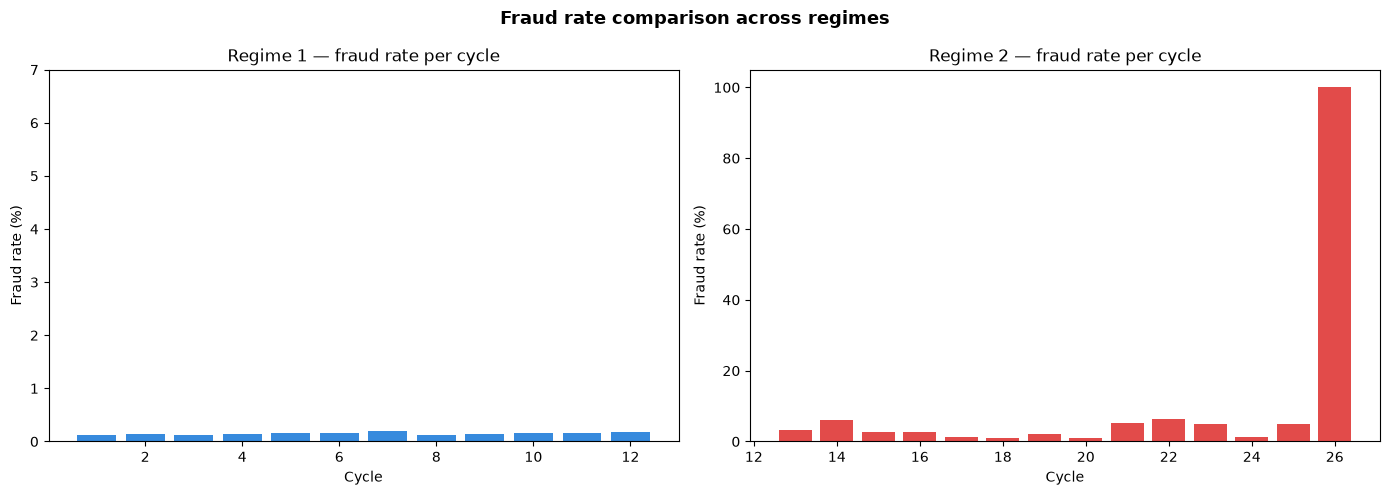

Figure saved.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime 1 fraud rate per cycle
axes[0].bar(cycle_stats_df['cycle'], 
            cycle_stats_df['fraud_rate'],
            color='#378ADD', width=0.8)
axes[0].set_title('Regime 1 — fraud rate per cycle')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].set_ylim(0, 7)

# Regime 2 fraud rate per cycle  
axes[1].bar(cycle_stats_r2_df['cycle'],
            cycle_stats_r2_df['fraud_rate'],
            color='#E24B4A', width=0.8)
axes[1].set_title('Regime 2 — fraud rate per cycle')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Fraud rate (%)')

plt.suptitle('Fraud rate comparison across regimes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/regime_fraud_rate_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## Decisions carried forward into notebook 04

1. Use regime 1 (cycles 1-12) snapshot graphs as the primary temporal 
   dataset for feature engineering and modelling
2. Regime 2 is documented for context and future work, not used in the 
   main pipeline
3. Feature engineering must include multiple structural measures (not 
   in-degree alone) since fraud concentration varies across cycles
4. No identity-based or historical features — fraud accounts don't persist, 
   so features must be computable from an account's current structural 
   position alone
5. PageRank (full graph and fraud subgraph, compared against in-degree) 
   remains deferred to notebook 04 as previously flagged